# The 18 ReEDS cases, assuming 100% SMR deployment

**What this notebook does.** The companion MC (`mc_cost_trajectories.ipynb`) already selects
and exports 18 ReEDS cases — but under winner-take-all, where some drawn futures resolve in
favor of large reactors and export a traditional build program. The mixed-build stress test
(`mixed_build_optimizer.ipynb`) then established that pure single-technology programs are
truly optimal, and the SMR program is the cheaper one in 76–89% of futures. The next phase of
the paper therefore **assumes the deployment mandate is met entirely with SMRs**, and this
notebook regenerates the 18 cases under that assumption:

1. re-run the companion notebook's own Monte Carlo — **the identical drawn worlds** (same
   draw code, same copula, same seed streams; asserted bit-for-bit against its per-draw
   export in QA-0) — with **SMRs receiving the entire build program** in every draw and
   large reactors receiving only international spillover (the counterfactual cost ReEDS sees
   if it ever considers building one anyway);
2. rank each schedule's draws by the discounted financed cost of the SMR program and select
   the joint draws nearest **P5 / P50 / P95** — three internally consistent futures per
   schedule, 18 cases total;
3. export every selected draw in ReEDS's own input formats (plant characteristics,
   financing/duration wiring, and the 18-case run matrix), round-trip-checked by the QA cells.

**Draw design:** verbatim the companion notebook's (S8 there) — one Gaussian copula joining
learning rate, anchor cost, and global deployment position, with both technologies at the
*same percentile* of their published ranges (comonotone; so the SMR is always the pricier,
faster-learning technology by construction). The mixed-build notebook's independent-draw
variant was a robustness device only; the paper's sample space is this one. The **only**
difference from the companion's 18 cases is that the sample space no longer contains
traditional build programs: every case is an SMR program, ranked and selected as such.

**Discipline reminder:** every cost trajectory is conditional on its imposed deployment
schedule — these are "what would it cost if we built this much" curves, never predictions.

**Naming:** cases are `smr100_{schedule}_{percentile}` (e.g. `smr100_mck_p50`), files
`nuclear_mc_smr100_*` / `financials_tech_mc_smr100_*` etc., run matrix
`cases_nuclearlearning_smr100.csv` — deliberately distinct from the earlier winner-take-all
export set (`*_mc_{sched}_{pct}`), which remains on disk until retired.

In [1]:
import json
import os
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Paths: anchored to this notebook's folder, never the launch directory ---
NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
assert (NB_DIR / "pris_loader.py").exists(), f"notebook folder not found from {Path.cwd()}"
REPO_ROOT = NB_DIR.parent.parent               # the ReEDS-nuclear-learning fork
EXPORTS = NB_DIR / "exports" / "smr100"
FIGURES = NB_DIR / "figures"
for d in (EXPORTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

import sys
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

# --- Reproducibility: one master seed, independent named streams. The world streams use
# the COMPANION notebook's names ("world/{schedule}") so the drawn worlds here are
# bit-identical to mc_cost_trajectories.ipynb's (QA-0 asserts this); streams unique to
# this notebook are prefixed "smr100/". ---
MASTER_SEED = 20260715

def rng_stream(name):
    """An independent, reproducible random generator tied to a label."""
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

# --- Analysis switches ---
COPULA_SET = "moderate"                # within-tech lr <-> boak correlation (as companions)
RANKING_FUNCTIONAL = "discounted_schedule_weighted"   # paper-plan issue-8 default
N_DRAWS = int(os.environ.get("SMR100_DRAWS", 10000))  # per schedule; env override for test runs

# --- Model frame (identical to the companion notebooks) ---
YEARS = np.arange(2024, 2051)
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030
N_BOAK_UNITS = 2.0
OMEGA = 1.0 / 3.0
CES_RHO_GRID = np.array([-2.0, -1.0, 0.0, 1.0])
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0
U_GRID = np.linspace(0.0, 1.0, 21)

print(f"notebook dir : {NB_DIR}")
print(f"switches     : copula={COPULA_SET}, ranking={RANKING_FUNCTIONAL}, draws/schedule={N_DRAWS}")
print("deployment   : 100% SMR (large reactors ride the international-spillover-only channel)")

notebook dir : C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc
switches     : copula=moderate, ranking=discounted_schedule_weighted, draws/schedule=10000
deployment   : 100% SMR (large reactors ride the international-spillover-only channel)


## Ported foundations

Everything below is ported verbatim from the companion notebooks (see `mc_cost_trajectories.ipynb`
S2–S7 for the full plain-language walkthroughs): the six schedules from the single-source-of-truth
CSV, the PRIS-based historical and international experience stocks, the learning-curve engine,
the INL construction-duration model, and the ReEDS financing replication.

In [2]:
US_GW_2024 = 97.0
OFFSET_GW = 3.0

US_SCHEDULES_CSV = REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv"
_sched_df = pd.read_csv(US_SCHEDULES_CSV, comment="#", index_col="year")
TOKEN_NAME = {"eia_aeo_high": "EIA 2026 AEO high", "abou_jaoude": "Abou-Jaoude mod",
              "iaea_high": "IAEA high", "mckinsey": "McKinsey GEP 2025",
              "cop28": "COP28 tripling pledge", "eo2025": "2025 EO"}
assert set(_sched_df.columns) == set(TOKEN_NAME), "US_SCHEDULES.csv columns changed"
assert list(_sched_df.index) == list(YEARS), "US_SCHEDULES.csv year grid changed"
US_SCHEDULES = {TOKEN_NAME[tok]: _sched_df[tok].to_numpy(float) for tok in TOKEN_NAME}
SCHED_ORDER = list(US_SCHEDULES)
SCEN_TOKEN = {v: k for k, v in TOKEN_NAME.items()}

REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues
FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

PIPE_END = 2034
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}
_ever = PRIS_UNITS[PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}
US_LICENSE_LIFE = 80.0
ONE_FACTOR_DELTA = 0.0

def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through 2034 (real units, no double counting)."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    ret = retirement_flow_gw(region, 60.0 + 20.0*u)
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

REGION_STOCK = {}
for r in REGIONS:
    m = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        flow = gross_additions_gw(r, u)
        flow = flow.copy(); flow[YEARS <= ANCHOR] = 0.0
        m[gi] = np.cumsum(flow) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m

# US gross GW added per year under each schedule (post-anchor), and the SMR unit counts
# for the 100%-SMR program. ZEROS_T is the large-reactor (international-only) channel.
US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)
GW_ADD, N_US_SMR = {}, {}
for name in SCHED_ORDER:
    cap = US_SCHEDULES[name] - OFFSET_GW
    dnet = np.diff(cap, prepend=cap[0])
    flow = np.clip(dnet + US_RET, 0.0, None)
    flow[YEARS <= ANCHOR] = 0.0
    GW_ADD[name] = flow
    N_US_SMR[name] = np.cumsum(flow) / TECH["smr"]["unit_gw"]
ZEROS_T = np.zeros(T)

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction")
print("SMR units by 2050 under 100%-SMR deployment, per schedule:")
for name in SCHED_ORDER:
    print(f"  {name:22s} {N_US_SMR[name][-1]:6.0f} SMR units ({GW_ADD[name].sum():.0f} GW)")

PRIS fleet loaded: 417 operational, 62 under construction
SMR units by 2050 under 100%-SMR deployment, per schedule:
  EIA 2026 AEO high          69 SMR units (21 GW)
  Abou-Jaoude mod           121 SMR units (36 GW)
  IAEA high                 252 SMR units (76 GW)
  McKinsey GEP 2025         345 SMR units (103 GW)
  COP28 tripling pledge     678 SMR units (203 GW)
  2025 EO                  1011 SMR units (303 GW)


In [3]:
# The OCC engine — verbatim companion port (mc_cost_trajectories.ipynb S5).
H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)

def experience_channels(world, tech, n_us):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T)."""
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_KV = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_KV += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    N_us = np.broadcast_to(np.asarray(n_us, float), (n, T))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0    # D8': US LWR history -> large only
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + world["s"].values[:, None]*(conv*H_ALL_W + S_KV)
    return own, oth

CES_EPS = 1e-8

def occ_paths_ces(world, tech, n_us, ces_rho=None):
    """Production OCC engine (companion D11/D12, verbatim). Returns $/kW (2022 USD)."""
    own, oth = experience_channels(world, tech, n_us)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def percentile_table(paths, ps=(5, 25, 50, 75, 95)):
    """Yearly percentiles of a (n_draws, T) trajectory array."""
    return pd.DataFrame({f"P{p}": np.percentile(paths, p, axis=0) for p in ps}, index=YEARS)

In [4]:
# Durations + ReEDS financing — verbatim companion ports (S6-S7 there).
DUR_UNITS = pl.duration_panel(PRIS_UNITS)
DUR_UNITS = DUR_UNITS[DUR_UNITS["family"].isin(["AP1000", "APR1400", "HPR1000"])].reset_index(drop=True)
DUR_UNITS = DUR_UNITS.rename(columns={"reactor_name": "unit"})

def fit_family_fe(df):
    """ln(duration) = family intercepts + b*ln(family sequence); returns (coefficients, residual sd)."""
    X = np.column_stack([np.ones(len(df)),
                         (df["family"] == "APR1400").astype(float),
                         (df["family"] == "HPR1000").astype(float),
                         np.log(df["family_seq"].astype(float))])
    Y = np.log(df["months"].values)
    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ beta
    return beta, resid.std(ddof=min(4, len(df)-1))

beta_hat, sig_hat = fit_family_fe(DUR_UNITS)

INL_DUR_MOD = np.array([118.0, 88.0, 74.0, 67.0, 62.0, 59.0, 56.0, 54.0, 52.0, 50.0])
INL_DUR_OPT = np.array([118.0, 70.0, 57.0, 49.0, 45.0, 42.0, 40.0, 38.0, 37.0, 36.0])
SMR_DUR_RATIO = 55.0/82.0
SMR_DUR_FLOOR = 43.0

def duration_paths(world, tech, n_us):
    """Construction duration (months, FNC -> COD) per draw-year, from the INL series curves."""
    n = len(world)
    N_us = np.broadcast_to(np.asarray(n_us, float), (n, T))
    n_own = N_us / world["n_vendors"].values[:, None]
    series = np.clip(2 + np.floor(n_own/2.0).astype(int), 2, len(INL_DUR_MOD))
    opt, mod = np.take(INL_DUR_OPT, series-1), np.take(INL_DUR_MOD, series-1)
    base = opt + world["dur_lambda"].values[:, None]*(mod - opt)
    if tech == "smr":
        base = np.maximum(base * SMR_DUR_RATIO, SMR_DUR_FLOOR)
    return base * np.exp(world["dur_z"].values[:, None]*sig_hat)

FIN_DIR = REPO_ROOT / "inputs" / "financials"

def load_reeds_financials():
    """ReEDS financial inputs on the YEARS grid, exactly as reeds/financials.py derives them."""
    sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
    infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
    sys_fin = sys_fin.merge(infl, on="t", how="left")
    sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                        + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                          * (1 - sys_fin["tax_rate"]) + 1)
    sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
    tech_fin = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
    tech_fin = tech_fin[tech_fin["i"].isin(["Nuclear", "Nuclear-SMR"])]
    dep = pd.read_csv(FIN_DIR / "depreciation_schedules_default.csv")
    cs = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")

    def on_years(col):
        s = sys_fin.set_index("t")[col].reindex(range(1990, YEARS[-1] + 1)).ffill()
        return s.loc[YEARS].to_numpy(float)

    out = {"interest_base": on_years("interest_rate_nom"), "tax_rate": on_years("tax_rate"),
           "d_nom": on_years("d_nom"), "d_real": on_years("d_real"),
           "pv_dep": {}, "risk_mult": {}, "eval_adj": {}, "sched": {}}
    SYS_EVAL_YEARS = 30
    sys_pvf_sum = (1 - (1/out["d_real"])**(SYS_EVAL_YEARS - 1)) / (out["d_real"] - 1.0) + 1
    REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
    for tech, iname in REEDS_TECH_NAME.items():
        row = tech_fin[tech_fin["i"] == iname].iloc[-1]
        dep_frac = dep[str(int(row["depreciation_sch"]))].to_numpy(float)
        out["pv_dep"][tech] = np.array([np.sum(dep_frac / dn**np.arange(1, 22))
                                        for dn in out["d_nom"]])
        eval_p = float(row["eval_period"])
        out["risk_mult"][tech] = 1.0 + float(row["finance_diff_real"]) * (
            (1 - (1/out["d_real"])**eval_p) / (out["d_real"] - 1.0))
        tech_pvf_sum = (1 - (1/out["d_real"])**(eval_p - 1)) / (out["d_real"] - 1.0) + 1
        out["eval_adj"][tech] = sys_pvf_sum / tech_pvf_sum
        frac = pd.to_numeric(cs[str(row["construction_sch"])], errors="coerce").fillna(0.0).to_numpy()
        out["sched"][tech] = frac[frac > 0]
    return out

FIN = load_reeds_financials()

def _resample_schedule(frac, n_years):
    """Stretch/compress a spend-fraction profile to `n_years` bins (sum to 1)."""
    frac = np.asarray(frac, float)
    n0 = len(frac)
    if n_years == n0:
        return frac / frac.sum()
    cdf = np.concatenate([[0.0], np.cumsum(frac)])
    xq = np.linspace(0.0, 1.0, n_years + 1)
    cdf_q = np.interp(xq, np.linspace(0.0, 1.0, n0 + 1), cdf)
    new = np.diff(cdf_q)
    return new / new.sum()

def ccmult_from_duration(duration_mo, interest_base, canonical_frac):
    """Construction-financing (IDC) multiplier for a learned duration (verbatim ReEDS port)."""
    n_years = int(round(duration_mo / 12.0))
    n_years = max(1, min(n_years, 10))
    x = _resample_schedule(canonical_frac, n_years)
    exps = np.arange(n_years) + 0.5
    return 1.0 + float(np.sum(x * (interest_base ** exps - 1.0)))

def ccmult_grid(dur_months, tech):
    """Vectorized ccmult for a (n_draws, T) duration array."""
    ib = FIN["interest_base"]
    table = np.empty((10 + 1, T))
    for n in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], n)
        exps = np.arange(n) + 0.5
        table[n] = 1.0 + (x[:, None] * (ib[None, :] ** exps[:, None] - 1.0)).sum(axis=0)
    n_years = np.clip(np.round(np.asarray(dur_months)/12.0).astype(int), 1, 10)
    return table[n_years, np.arange(T)[None, :]]

def fin_mult_rest(tech, use_itc=False):
    """Everything in ReEDS's cost_cap_fin_mult EXCEPT ccmult, per year (T,) — verbatim port."""
    assert not use_itc, "ITC variant deliberately not implemented"
    tax, pv_dep = FIN["tax_rate"], FIN["pv_dep"][tech]
    return (1.0/(1.0 - tax)) * (1.0 - tax*pv_dep) * FIN["risk_mult"][tech] * FIN["eval_adj"][tech]

FIN_REST = {tech: fin_mult_rest(tech) for tech in TECH}
DISC = np.cumprod(np.where(YEARS > ANCHOR, FIN["d_real"], 1.0))   # discount to 2030
print(f"foundations loaded: duration panel {len(DUR_UNITS)} units (sd {sig_hat:.3f}); "
      f"ccmult(72mo, 8%, '6') = {ccmult_from_duration(72.0, 1.08, FIN['sched']['large']):.6f}")

foundations loaded: duration panel 21 units (sd 0.116); ccmult(72mo, 8%, '6') = 1.268124


## The draw and the six Monte Carlos

The draw is the companion notebook's, **verbatim** (see its S4/S8 for the full rationale): one
Gaussian copula joins the three latent uncertainty axes — learning rate, 2030 anchor cost, and
global deployment position `u` — with learning rate and anchor cost modestly negatively
correlated under the default "moderate" set. Both technologies sit at the *same percentile* of
their published ranges within a draw, so the SMR is always the more expensive, faster-learning
technology by construction. The remaining inputs (international spillover scale `s`, vendor
count, tiny-base/full-stock convention, CES substitution parameter, two duration inputs) are
independent draws. Same code + same seed streams = **the identical worlds the companion
notebook analyzed** (QA-0 asserts this bit-for-bit).

For each schedule we then compute, for every draw:

- the **SMR full-program path**: overnight cost, construction duration, IDC multiplier, and
  financed capital cost with the entire schedule feeding SMR experience;
- the **large-reactor counterfactual path**: the same quantities with *zero* US builds — its
  cost falls only through international spillover. This is what ReEDS will see as the price
  of large nuclear if it ever considers it (it should decline only mildly).

In [5]:
# Ported verbatim from mc_cost_trajectories.ipynb S8.
RHO_SETS = {"zero": 0.0, "moderate": -0.3, "strong": -0.6}
LATENTS = ["lr", "boak", "u"]

def corr_matrix(rho_key):
    C = np.eye(3)
    C[0, 1] = C[1, 0] = RHO_SETS[rho_key]
    ev = np.linalg.eigvalsh(C)
    assert ev.min() > 1e-10, f"correlation matrix '{rho_key}' is not positive definite: {ev}"
    return C

def draw_world(n, rho_key, rng):
    """Draw n worlds: every uncertain input, one row per draw (companion S8, verbatim)."""
    Z = rng.standard_normal((n, 3)) @ np.linalg.cholesky(corr_matrix(rho_key)).T
    U = stats.norm.cdf(Z)                                   # Gaussian copula -> uniforms
    w = pd.DataFrame(index=range(n))
    for tech in TECH:
        t = TECH[tech]
        w[f"lr_{tech}"] = t["lr_lo"] + U[:, 0]*(t["lr_hi"] - t["lr_lo"])      # comonotone across techs
        w[f"boak_{tech}"] = t["boak_lo"] + U[:, 1]*(t["boak_hi"] - t["boak_lo"])
    w["u"] = U[:, 2]                                        # global deployment position
    w["s"] = rng.uniform(0.0, 1.0, n)                       # spillover scale
    w["n_vendors"] = rng.integers(4, 9, n)                  # vendor count m
    w["conv_full"] = rng.integers(0, 2, n)                  # 0 = tiny-base, 1 = full-stock
    w["ces_rho"] = rng.choice(CES_RHO_GRID, size=n)         # channel-substitution stratum
    w["dur_lambda"] = rng.uniform(0.0, 1.0, n)              # duration scenario position
    w["dur_z"] = rng.standard_normal(n)                     # persistent duration project noise
    return w

WORLDS, results = {}, {}
for sched in SCHED_ORDER:
    # The COMPANION's stream names, deliberately: identical worlds to mc_cost_trajectories.ipynb
    world = draw_world(N_DRAWS, COPULA_SET, rng_stream(f"world/{SCEN_TOKEN[sched]}"))
    WORLDS[sched] = world
    r = {}
    for tech, n_us in (("smr", N_US_SMR[sched]), ("large", ZEROS_T)):
        r[f"occ_{tech}"] = occ_paths_ces(world, tech, n_us)
        r[f"dur_{tech}"] = duration_paths(world, tech, n_us)
        r[f"ccmult_{tech}"] = ccmult_grid(r[f"dur_{tech}"], tech)
        r[f"fincapex_{tech}"] = r[f"occ_{tech}"] * r[f"ccmult_{tech}"] * FIN_REST[tech][None, :]
    results[sched] = r

print(f"drew {N_DRAWS} worlds x {len(SCHED_ORDER)} schedules (companion draw, comonotone)")
print("\n2050 SMR OCC and financed CAPEX by schedule ($/kW 2022, P5 / P50 / P95):")
for sched in SCHED_ORDER:
    o = results[sched]["occ_smr"][:, yi(2050)]
    f = results[sched]["fincapex_smr"][:, yi(2050)]
    print(f"  {sched:22s} OCC {np.percentile(o,5):5,.0f} /{np.percentile(o,50):6,.0f} /"
          f"{np.percentile(o,95):6,.0f}   financed {np.percentile(f,5):5,.0f} /"
          f"{np.percentile(f,50):6,.0f} /{np.percentile(f,95):6,.0f}")

drew 10000 worlds x 6 schedules (companion draw, comonotone)

2050 SMR OCC and financed CAPEX by schedule ($/kW 2022, P5 / P50 / P95):
  EIA 2026 AEO high      OCC 3,396 / 5,373 / 8,055   financed 4,492 / 7,137 /10,724
  Abou-Jaoude mod        OCC 2,959 / 4,944 / 7,761   financed 3,929 / 6,565 /10,269
  IAEA high              OCC 2,426 / 4,382 / 7,368   financed 3,207 / 5,810 / 9,752
  McKinsey GEP 2025      OCC 2,234 / 4,186 / 7,198   financed 2,970 / 5,556 / 9,554
  COP28 tripling pledge  OCC 1,822 / 3,674 / 6,788   financed 2,421 / 4,871 / 9,012
  2025 EO                OCC 1,641 / 3,399 / 6,533   financed 2,171 / 4,497 / 8,662


## Selecting the 18 cases

Within each schedule's Monte Carlo, draws are ranked by the **discounted, GW-weighted financed
cost of the SMR program** (the same "issue-8 default" functional the companion notebooks use).
The exported cases are the actual joint draws sitting nearest the 5th, 50th, and 95th
percentiles of that ranking — *cheap SMR future / central future / expensive SMR future* — so
every case is one internally consistent world, never a mix of marginal percentiles. The full
parameter record of each selected draw is frozen to `exports/smr100/selected_draws.csv`.

In [6]:
SHORT = {"eia_aeo_high": "eia", "abou_jaoude": "aj", "iaea_high": "iaea",
         "mckinsey": "mck", "cop28": "cop28", "eo2025": "eo"}
PCTS = [("p05", 0.05), ("p50", 0.50), ("p95", 0.95)]

def rank_smr(sched):
    """Program-cost score per draw: discounted GW-weighted SMR financed CAPEX (lower = cheaper)."""
    w_t = GW_ADD[sched] / DISC
    return results[sched]["fincapex_smr"] @ w_t

CASES = {}           # CASES[case_name] -> dict describing the selected draw
for sched in SCHED_ORDER:
    order = np.argsort(rank_smr(sched))                 # cheapest SMR program first
    for pname, q in PCTS:
        d = int(order[int(round(q * (len(order) - 1)))])
        case = f"smr100_{SHORT[SCEN_TOKEN[sched]]}_{pname}"
        w = WORLDS[sched].loc[d]
        CASES[case] = {
            "case": case, "schedule": sched, "scen_token": SCEN_TOKEN[sched],
            "percentile": pname, "draw": d, "winner": "smr",   # by design: 100% SMR deployment
            "lr_large": round(w["lr_large"], 4), "lr_smr": round(w["lr_smr"], 4),
            "boak_large": round(w["boak_large"], 0), "boak_smr": round(w["boak_smr"], 0),
            "u": round(w["u"], 3), "s_spill": round(w["s"], 3),
            "n_vendors": int(w["n_vendors"]),
            "convention": "full-stock" if w["conv_full"] else "tiny-base",
            "ces_rho": float(w["ces_rho"]),
            "dur_lambda": round(w["dur_lambda"], 3), "dur_z": round(w["dur_z"], 3),
        }
        for tech in TECH:
            for y in (2030, 2040, 2050):
                CASES[case][f"occ_{tech}_{y}"] = round(float(results[sched][f"occ_{tech}"][d, yi(y)]), 0)
                CASES[case][f"dur_{tech}_{y}"] = round(float(results[sched][f"dur_{tech}"][d, yi(y)]), 0)

selected = pd.DataFrame(CASES).T.set_index("case")
selected.to_csv(EXPORTS / "selected_draws.csv")
print(f"selected {len(CASES)} cases (6 schedules x P5/P50/P95 of SMR program cost)")
selected[["schedule", "percentile", "lr_smr", "boak_smr", "u", "n_vendors", "convention",
          "occ_smr_2050", "occ_large_2050"]]

selected 18 cases (6 schedules x P5/P50/P95 of SMR program cost)


,schedule,percentile,lr_smr,boak_smr,u,n_vendors,convention,occ_smr_2050,occ_large_2050
case,,,,,,,,,
smr100_eia_p05,EIA 2026 AEO high,p05,0.1436,5692.0,0.13,7,full-stock,3384.0,5350.0
smr100_eia_p50,EIA 2026 AEO high,p50,0.0957,7761.0,0.918,7,full-stock,5520.0,6506.0
smr100_eia_p95,EIA 2026 AEO high,p95,0.0303,9072.0,0.782,8,full-stock,8219.0,7234.0
smr100_aj_p05,Abou-Jaoude mod,p05,0.148,6761.0,0.065,4,tiny-base,2898.0,5903.0
smr100_aj_p50,Abou-Jaoude mod,p50,0.081,7562.0,0.739,7,tiny-base,5175.0,6082.0
smr100_aj_p95,Abou-Jaoude mod,p95,0.0324,8893.0,0.293,6,full-stock,8241.0,7076.0
smr100_iaea_p05,IAEA high,p05,0.1575,6022.0,0.377,8,full-stock,2425.0,5533.0
smr100_iaea_p50,IAEA high,p50,0.0892,8345.0,0.458,4,full-stock,4491.0,6829.0
smr100_iaea_p95,IAEA high,p95,0.0513,9797.0,0.992,8,tiny-base,7367.0,7617.0


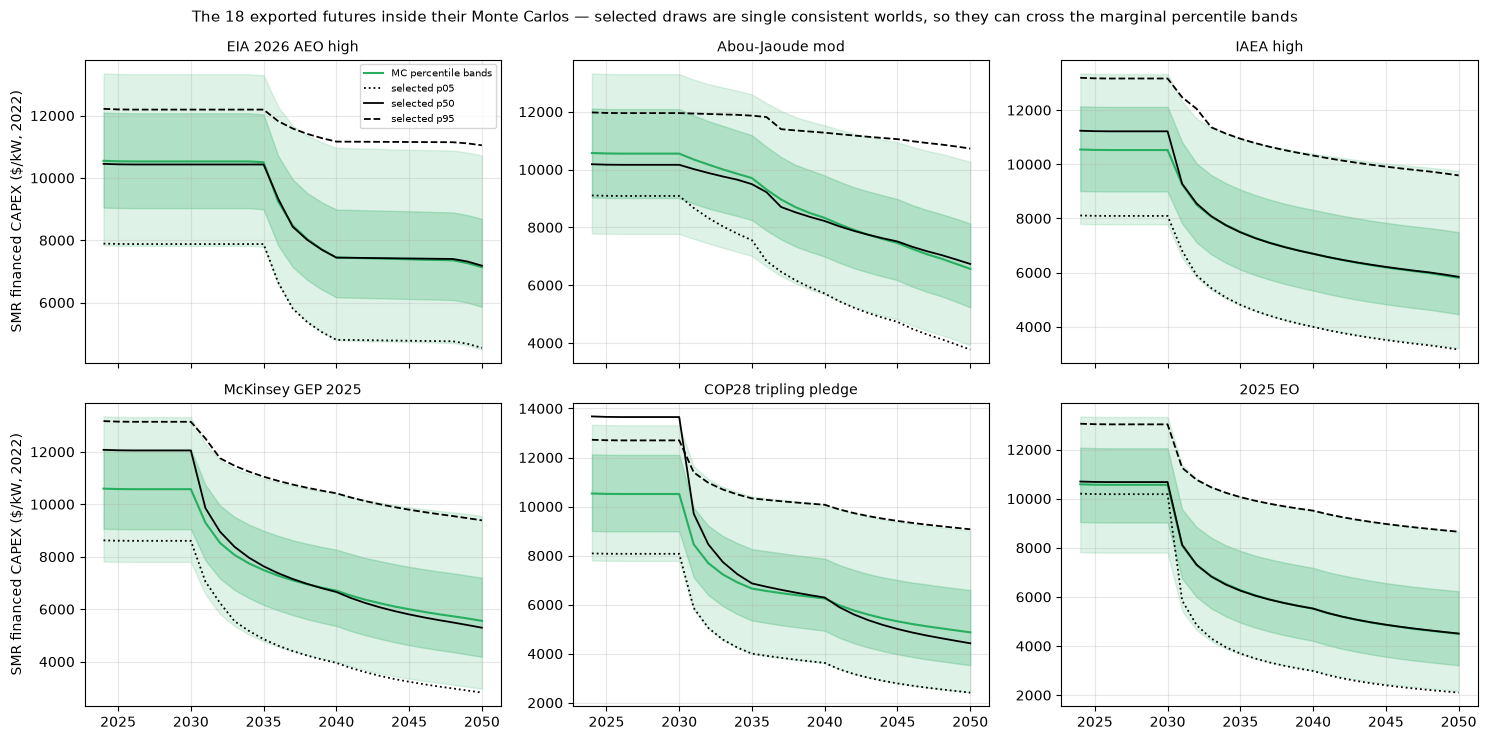

In [7]:
# Figure: each schedule's SMR financed-CAPEX fan with its three selected draws overlaid —
# a visual check that the selections sit where they should in the distribution.
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True)
for ax, sched in zip(axes.ravel(), SCHED_ORDER):
    fc = results[sched]["fincapex_smr"]
    pct = percentile_table(fc)
    ax.fill_between(YEARS, pct["P5"], pct["P95"], alpha=0.15, color="#27ae60")
    ax.fill_between(YEARS, pct["P25"], pct["P75"], alpha=0.25, color="#27ae60")
    ax.plot(YEARS, pct["P50"], color="#27ae60", lw=1.5, label="MC percentile bands")
    for pname, ls in (("p05", ":"), ("p50", "-"), ("p95", "--")):
        case = f"smr100_{SHORT[SCEN_TOKEN[sched]]}_{pname}"
        d = CASES[case]["draw"]
        ax.plot(YEARS, fc[d], color="k", ls=ls, lw=1.3, label=f"selected {pname}")
    ax.set_title(sched, fontsize=10)
    ax.grid(alpha=0.3)
    if sched == SCHED_ORDER[0]:
        ax.legend(fontsize=7)
for ax in axes[:, 0]:
    ax.set_ylabel("SMR financed CAPEX ($/kW, 2022)")
fig.suptitle("The 18 exported futures inside their Monte Carlos — selected draws are single "
             "consistent worlds, so they can cross the marginal percentile bands", fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES / "smr100_selected_draws.png", dpi=200, bbox_inches="tight")
plt.show()

## Exports to ReEDS

Three export families, formats ported verbatim from the companion notebook's QA'd S12:

1. **Plant characteristics** — per case and technology, the ATB-2024-moderate file with
   `capcost` overwritten from 2030 on by the selected draw's OCC path (2022 $/kW; pre-anchor
   years keep ATB values), plus idempotent `dollaryear.csv` registration. The SMR file carries
   the full-program learning path; the large-reactor file carries the international-only
   counterfactual.
2. **Financing/duration wiring** — the shared `construction_schedules_mc.csv` (re-written,
   byte-identical: the '6'/'3B' spend profiles restretched to 1–10 years as columns NL1–NL10 /
   NS1–NS10), plus per-case `financials_tech_mc_smr100_*` files whose `construction_sch(i,t)`
   labels encode each year's learned duration (this is what actually drives ReEDS's IDC), and
   `construction_times_mc_smr100_*` for tax-credit safe-harbor consistency.
3. **The run matrix** — `cases_nuclearlearning_smr100.csv` at the repo root: 18 cases, each
   pointing at its schedule's mandate trajectory and its own cost/financing files, with
   learning OFF (costs are exogenous per-case draws by design).

In [8]:
# Export 1: plant-characteristics files + dollaryear registration
PLANTCHAR_DIR = REPO_ROOT / "inputs" / "plant_characteristics"
REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
ATB_FILE = {"large": "nuclear_ATB_2024_moderate.csv", "smr": "nuclear-smr_ATB_2024_moderate.csv"}
atb_base = {t: pd.read_csv(PLANTCHAR_DIR / ATB_FILE[t]) for t in TECH}

def plantchar_name(tech, case):
    return f"{'nuclear' if tech == 'large' else 'nuclear-smr'}_mc_{case}"

written_plantchar = []
for case, info in CASES.items():
    sched, d = info["schedule"], info["draw"]
    for tech in TECH:
        occ = results[sched][f"occ_{tech}"][d]                # (T,) 2024-2050, 2022 $/kW
        df = atb_base[tech].copy()
        for t_i, y in enumerate(YEARS):
            if y >= ANCHOR:                                   # pre-anchor years keep ATB values
                df.loc[df["t"] == y, "capcost"] = round(float(occ[t_i]), 1)
        name = plantchar_name(tech, case)
        df.to_csv(PLANTCHAR_DIR / f"{name}.csv", index=False)
        written_plantchar.append(name)

doll_path = PLANTCHAR_DIR / "dollaryear.csv"
doll = pd.read_csv(doll_path)
new_rows = [{"Scenario": n, "Dollar.Year": 2022} for n in written_plantchar
            if n not in set(doll["Scenario"])]
if new_rows:
    doll = pd.concat([doll, pd.DataFrame(new_rows)], ignore_index=True)
    doll.to_csv(doll_path, index=False)
print(f"wrote {len(written_plantchar)} plant-characteristics files; "
      f"registered {len(new_rows)} new dollaryear rows (idempotent)")

wrote 36 plant-characteristics files; registered 0 new dollaryear rows (idempotent)


In [9]:
# Export 2: shared construction-schedules columns + per-case financials_tech / construction_times
cs_mc = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")
for tech, prefix in [("large", "NL"), ("smr", "NS")]:
    for n in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], n)
        col = np.zeros(len(cs_mc))
        col[1:n+1] = x                        # row 0 is the 'NA' (exponent-0) row
        cs_mc[f"{prefix}{n}"] = np.round(col, 6)
cs_mc.to_csv(FIN_DIR / "construction_schedules_mc.csv", index=False)

def dur_to_years(dur_row):
    """Drawn duration path (months, (T,)) -> ReEDS spend-years labels per year."""
    return np.clip(np.round(np.asarray(dur_row) / 12.0).astype(int), 1, 10)

ft_base = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
ct_base = pd.read_csv(FIN_DIR / "construction_times_default.csv")
SCH_PREFIX = {"large": "NL", "smr": "NS"}

for case, info in CASES.items():
    sched, d = info["schedule"], info["draw"]
    ft = ft_base.copy()
    ft["construction_sch"] = ft["construction_sch"].astype(str)
    ct = ct_base.copy()
    for tech in TECH:
        n_years = dur_to_years(results[sched][f"dur_{tech}"][d])        # (T,)
        iname = REEDS_TECH_NAME[tech]
        for t_i, y in enumerate(YEARS):
            if y >= ANCHOR:
                mask = (ft["i"] == iname) & (ft["t"] == y)
                ft.loc[mask, "construction_sch"] = f"{SCH_PREFIX[tech]}{n_years[t_i]}"
                ct.loc[(ct["i"] == iname) & (ct["t_online"] == y),
                       "construction_time"] = int(n_years[t_i])
    ft.to_csv(FIN_DIR / f"financials_tech_mc_{case}.csv", index=False)
    ct.to_csv(FIN_DIR / f"construction_times_mc_{case}.csv", index=False)
print(f"wrote construction_schedules_mc.csv (+20 profile columns) and "
      f"{len(CASES)} financials_tech_mc_* + {len(CASES)} construction_times_mc_* files")

wrote construction_schedules_mc.csv (+20 profile columns) and 18 financials_tech_mc_* + 18 construction_times_mc_* files


In [10]:
# Export 3: the ReEDS cases file - 18 cases, Default Value column carries the shared design
case_rows = {
    "ignore": ["0"] + [""] * len(CASES),
    "timetype": ["seq"] + [""] * len(CASES),
    "endyear": ["2050"] + [""] * len(CASES),
    "GSw_NuclearCapMandate": ["1"] + [""] * len(CASES),        # floor; =2 flips to equality (issue 6)
    "GSw_NuclearCapMandate_Scale": ["1"] + [""] * len(CASES),
    "GSw_NuclearLearning": ["0"] + [""] * len(CASES),          # exogenous costs by design
    "construction_schedules_suffix": ["mc"] + [""] * len(CASES),
    "GSw_NuclearCapMandateScen": [""] + [CASES[c]["scen_token"] for c in CASES],
    "plantchar_nuclear": [""] + [plantchar_name("large", c) for c in CASES],
    "plantchar_nuclear_smr": [""] + [plantchar_name("smr", c) for c in CASES],
    "financials_tech_suffix": [""] + [f"mc_{c}" for c in CASES],
    "construction_times_suffix": [""] + [f"mc_{c}" for c in CASES],
}
cases_out = pd.DataFrame(case_rows, index=["Default Value"] + list(CASES)).T
CASES_PATH = REPO_ROOT / "cases_nuclearlearning_smr100.csv"
cases_out.to_csv(CASES_PATH, index_label="")
print(f"wrote {CASES_PATH.name}: {len(CASES)} cases "
      f"(launch: python runreeds.py -b <batch> -c nuclearlearning_smr100)")
cases_out.head(12)

wrote cases_nuclearlearning_smr100.csv: 18 cases (launch: python runreeds.py -b <batch> -c nuclearlearning_smr100)


,Default Value,smr100_eia_p05,smr100_eia_p50,smr100_eia_p95,smr100_aj_p05,smr100_aj_p50,smr100_aj_p95,smr100_iaea_p05,smr100_iaea_p50,smr100_iaea_p95,smr100_mck_p05,smr100_mck_p50,smr100_mck_p95,smr100_cop28_p05,smr100_cop28_p50,smr100_cop28_p95,smr100_eo_p05,smr100_eo_p50,smr100_eo_p95
ignore,0,,,,,,,,,,,,,,,,,,
timetype,seq,,,,,,,,,,,,,,,,,,
endyear,2050,,,,,,,,,,,,,,,,,,
GSw_NuclearCapMandate,1,,,,,,,,,,,,,,,,,,
GSw_NuclearCapMandate_Scale,1,,,,,,,,,,,,,,,,,,
GSw_NuclearLearning,0,,,,,,,,,,,,,,,,,,
construction_schedules_suffix,mc,,,,,,,,,,,,,,,,,,
GSw_NuclearCapMandateScen,,eia_aeo_high,eia_aeo_high,eia_aeo_high,abou_jaoude,abou_jaoude,abou_jaoude,iaea_high,iaea_high,iaea_high,mckinsey,mckinsey,mckinsey,cop28,cop28,cop28,eo2025,eo2025,eo2025
plantchar_nuclear,,nuclear_mc_smr100_eia_p05,nuclear_mc_smr100_eia_p50,nuclear_mc_smr100_eia_p95,nuclear_mc_smr100_aj_p05,nuclear_mc_smr100_aj_p50,nuclear_mc_smr100_aj_p95,nuclear_mc_smr100_iaea_p05,nuclear_mc_smr100_iaea_p50,nuclear_mc_smr100_iaea_p95,nuclear_mc_smr100_mck_p05,nuclear_mc_smr100_mck_p50,nuclear_mc_smr100_mck_p95,nuclear_mc_smr100_cop28_p05,nuclear_mc_smr100_cop28_p50,nuclear_mc_smr100_cop28_p95,nuclear_mc_smr100_eo_p05,nuclear_mc_smr100_eo_p50,nuclear_mc_smr100_eo_p95
plantchar_nuclear_smr,,nuclear-smr_mc_smr100_eia_p05,nuclear-smr_mc_smr100_eia_p50,nuclear-smr_mc_smr100_eia_p95,nuclear-smr_mc_smr100_aj_p05,nuclear-smr_mc_smr100_aj_p50,nuclear-smr_mc_smr100_aj_p95,nuclear-smr_mc_smr100_iaea_p05,nuclear-smr_mc_smr100_iaea_p50,nuclear-smr_mc_smr100_iaea_p95,nuclear-smr_mc_smr100_mck_p05,nuclear-smr_mc_smr100_mck_p50,nuclear-smr_mc_smr100_mck_p95,nuclear-smr_mc_smr100_cop28_p05,nuclear-smr_mc_smr100_cop28_p50,nuclear-smr_mc_smr100_cop28_p95,nuclear-smr_mc_smr100_eo_p05,nuclear-smr_mc_smr100_eo_p50,nuclear-smr_mc_smr100_eo_p95


## QA suite

One check per cell, self-announcing PASS/FAIL: identity with the companion notebook's drawn
worlds, the draw's implied orderings, the anchor identity, the financing regression pin,
selection sanity, and — most importantly — the full export round-trip: every written file is
re-read and verified against the in-memory arrays and against `cases.csv`'s own validation
rules.

In [11]:
# QA-0 — same sample space as the companion: if mc_cost_trajectories.ipynb's per-draw export
# (exports/mc_perdraw.npz) is present and was generated at the same draw count, this
# notebook's drawn worlds must match it draw-for-draw (same code, same seed streams), and the
# SMR full-program trajectory arrays must match too. Tolerance is floating-point rounding
# only (rtol 1e-9): the companion runs on a different kernel/BLAS build, which perturbs the
# copula matmul in the last bit (~2e-16 relative) — the underlying random stream is identical
# (the plain-rng columns like `s` match bit-for-bit). Skips gracefully if absent/stale.
_npz_path = NB_DIR / "exports" / "mc_perdraw.npz"
if _npz_path.exists():
    _pd_npz = np.load(_npz_path, allow_pickle=False)
    _tok0 = SCEN_TOKEN[SCHED_ORDER[0]]
    if _pd_npz[f"worlds_{_tok0}"].shape[0] != N_DRAWS:
        print(f"QA-0 SKIPPED: mc_perdraw.npz has {_pd_npz[f'worlds_{_tok0}'].shape[0]} draws, "
              f"this run has {N_DRAWS} — re-run the companion notebook to compare")
    else:
        cols = list(_pd_npz["world_columns"].astype(str))
        for sched in SCHED_ORDER:
            tok = SCEN_TOKEN[sched]
            assert cols == list(WORLDS[sched].columns), "world column layout diverged"
            ours_w = WORLDS[sched].to_numpy(dtype=float)
            assert np.allclose(_pd_npz[f"worlds_{tok}"], ours_w, rtol=1e-9, atol=0), tok
            assert np.array_equal(_pd_npz[f"worlds_{tok}"][:, cols.index("s")],
                                  WORLDS[sched]["s"].to_numpy()), (tok, "stream identity")
            for ch, ours in (("occ", "occ_smr"), ("dur", "dur_smr"),
                             ("ccmult", "ccmult_smr"), ("fincapex", "fincapex_smr")):
                assert np.allclose(_pd_npz[f"{ch}_{tok}_smr"], results[sched][ours],
                                   rtol=1e-9, atol=0), (tok, ch)
        print("QA-0 PASSED: drawn worlds and SMR full-program trajectories match the companion "
              "notebook's mc_perdraw.npz draw-for-draw (bit-identical random stream; "
              "differences bounded by cross-kernel floating-point rounding) — "
              "same sample space by construction")
else:
    print("QA-0 SKIPPED: exports/mc_perdraw.npz not found (run the companion notebook to enable "
          "the sample-space cross-check)")

QA-0 PASSED: drawn worlds and SMR full-program trajectories match the companion notebook's mc_perdraw.npz draw-for-draw (bit-identical random stream; differences bounded by cross-kernel floating-point rounding) — same sample space by construction


In [12]:
# QA-1 — the comonotone draw implies the honest orderings on every draw (the SMR range starts
# higher and ends higher, so same-percentile draws always have the SMR pricier at the anchor
# and learning at least as fast); marginals inside published ranges.
for sched in SCHED_ORDER:
    w = WORLDS[sched]
    assert (w["boak_smr"] > w["boak_large"]).all(), sched
    assert (w["lr_smr"] >= w["lr_large"]).all(), sched
    for tech in TECH:
        t = TECH[tech]
        assert w[f"boak_{tech}"].between(t["boak_lo"], t["boak_hi"]).all(), (sched, tech)
        assert w[f"lr_{tech}"].between(t["lr_lo"], t["lr_hi"]).all(), (sched, tech)
print("QA-1 PASSED: boak_smr > boak_large and lr_smr >= lr_large on every draw "
      "(implied by the comonotone draw); all marginals inside their published ranges")

QA-1 PASSED: boak_smr > boak_large and lr_smr >= lr_large on every draw (implied by the comonotone draw); all marginals inside their published ranges


In [13]:
# QA-2 — anchor identity: OCC(2030) == the drawn anchor cost, every draw, both channels.
for sched in SCHED_ORDER:
    w = WORLDS[sched]
    for tech in TECH:
        assert np.allclose(results[sched][f"occ_{tech}"][:, yi(ANCHOR)],
                           w[f"boak_{tech}"].values), (sched, tech)
print("QA-2 PASSED: every draw hits its anchor cost exactly at 2030 "
      "(SMR full-program channel and large international-only channel)")

QA-2 PASSED: every draw hits its anchor cost exactly at 2030 (SMR full-program channel and large international-only channel)


In [14]:
# QA-3 — financing regression pin + the large counterfactual behaves as designed:
# with zero US builds its OCC declines only mildly (international spillover only).
_ccm = ccmult_from_duration(72.0, 1.08, FIN["sched"]["large"])
assert abs(_ccm - 1.268124) < 1e-5, _ccm
_decline = 1.0 - results[SCHED_ORDER[-1]]["occ_large"][:, yi(2050)] \
                 / results[SCHED_ORDER[-1]]["occ_large"][:, yi(ANCHOR)]
assert _decline.max() < 0.35, "large intl-only channel declining implausibly fast"
print(f"QA-3 PASSED: ccmult pin 1.268124 reproduced; large-reactor counterfactual OCC declines "
      f"{np.percentile(_decline, 50):.1%} (median) to {_decline.max():.1%} (max) by 2050 — "
      "international spillover only, as designed")

QA-3 PASSED: ccmult pin 1.268124 reproduced; large-reactor counterfactual OCC declines 0.4% (median) to 33.9% (max) by 2050 — international spillover only, as designed


In [15]:
# QA-4 — selection sanity: within each schedule the three selected draws' SMR program scores
# are ordered p05 < p50 < p95, and each sits at its claimed percentile of the ranking.
for sched in SCHED_ORDER:
    r = rank_smr(sched)
    scores = {}
    for pname, q in PCTS:
        case = f"smr100_{SHORT[SCEN_TOKEN[sched]]}_{pname}"
        d = CASES[case]["draw"]
        scores[pname] = r[d]
        frac = (r < r[d]).mean()
        assert abs(frac - q) < 0.01, (sched, pname, frac)
    assert scores["p05"] < scores["p50"] < scores["p95"], sched
print("QA-4 PASSED: selected draws sit at their claimed percentiles of the SMR program-cost "
      "ranking, strictly ordered p05 < p50 < p95 in every schedule")

QA-4 PASSED: selected draws sit at their claimed percentiles of the SMR program-cost ranking, strictly ordered p05 < p50 < p95 in every schedule


In [16]:
# QA-5 — export round-trips (ported from the companion's QA11):
import re as _re

# (a) plantchar round-trip: capcost 2030-2050 equals the selected draw's OCC path; pre-anchor = ATB
for case, info in CASES.items():
    sched, d = info["schedule"], info["draw"]
    for tech in TECH:
        back = pd.read_csv(PLANTCHAR_DIR / f"{plantchar_name(tech, case)}.csv").set_index("t")
        occ = results[sched][f"occ_{tech}"][d]
        for y in (2030, 2040, 2050):
            assert abs(back.loc[y, "capcost"] - occ[yi(y)]) < 0.1, (case, tech, y)
        assert abs(back.loc[2025, "capcost"] - atb_base[tech].set_index("t").loc[2025, "capcost"]) < 1e-6

# (b) ccmult from the WRITTEN schedule labels equals the notebook's ccmult at rounded years
cs_back = pd.read_csv(FIN_DIR / "construction_schedules_mc.csv")
for case, info in list(CASES.items())[::5] + [list(CASES.items())[-1]]:
    sched, d = info["schedule"], info["draw"]
    ft_back = pd.read_csv(FIN_DIR / f"financials_tech_mc_{case}.csv")
    for tech in TECH:
        iname = REEDS_TECH_NAME[tech]
        for y in (2030, 2040, 2050):
            label = ft_back.loc[(ft_back["i"] == iname) & (ft_back["t"] == y),
                                "construction_sch"].iloc[0]
            frac = pd.to_numeric(cs_back[label], errors="coerce").fillna(0.0).to_numpy()
            frac = frac[frac > 0]
            exps = np.arange(len(frac)) + 0.5
            ccm_file = 1.0 + float(np.sum(frac/frac.sum() * (FIN["interest_base"][yi(y)]**exps - 1.0)))
            mo = results[sched][f"dur_{tech}"][d, yi(y)]
            ccm_nb = ccmult_from_duration(mo, FIN["interest_base"][yi(y)], FIN["sched"][tech])
            assert abs(ccm_file - ccm_nb) < 2e-5, (case, tech, y, ccm_file, ccm_nb)

# (c) the cases file validates against cases.csv's own index and Choices regexes
cases_master = pd.read_csv(REPO_ROOT / "cases.csv", index_col=0)
cases_back = pd.read_csv(CASES_PATH, index_col=0)
for switch in cases_back.index:
    if switch == "ignore":
        continue
    assert switch in cases_master.index, f"unknown switch {switch}"
    choices = str(cases_master.loc[switch, "Choices"])
    for col in cases_back.columns:
        val = cases_back.loc[switch, col]
        if pd.isna(val) or val == "":
            continue
        if choices in ("N/A", "nan", "int", "float"):
            continue
        tokens = [c.strip() for c in _re.split("[;,]", choices)]
        assert any(_re.match(tok + "$", str(val)) for tok in tokens), (switch, val, choices)

# (d) dollaryear registration is idempotent and complete
doll_back = pd.read_csv(doll_path)
for n in written_plantchar:
    assert (doll_back["Scenario"] == n).sum() == 1, n

print("QA-5 PASSED: plantchar round-trip, written-label ccmult identity, cases-file validation "
      "against cases.csv Choices, and dollaryear idempotency all hold")

QA-5 PASSED: plantchar round-trip, written-label ccmult identity, cases-file validation against cases.csv Choices, and dollaryear idempotency all hold


## Run metadata

In [17]:
import hashlib
import subprocess
from datetime import datetime, timezone

def _sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]

try:
    _git = subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT,
                          capture_output=True, text=True).stdout.strip()
except Exception:
    _git = "unavailable"

meta = {
    "notebook": "smr100_case_export.ipynb",
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "fork_git_head": _git,
    "master_seed": MASTER_SEED,
    "stream_prefix": "smr100/",
    "design": {"deployment": "100% SMR (winner-take-all resolved in favor of SMR; see "
                             "mc_cost_trajectories.ipynb S10 and mixed_build_optimizer.ipynb)",
               "draw": "the companion notebook's comonotone 3-latent copula draw, verbatim, "
                       "on the companion's own seed streams (world/{schedule}) — identical "
                       "worlds, asserted in QA-0 when mc_perdraw.npz is present",
               "large_channel": "international spillover only (zero US builds)",
               "ranking": RANKING_FUNCTIONAL, "copula_set": COPULA_SET, "n_draws": N_DRAWS},
    "cases": list(CASES),
    "reeds_files": {"cases_file": CASES_PATH.name,
                    "plantchar": sorted(written_plantchar),
                    "financials_tech": [f"financials_tech_mc_{c}.csv" for c in CASES],
                    "construction_times": [f"construction_times_mc_{c}.csv" for c in CASES],
                    "construction_schedules": "construction_schedules_mc.csv"},
    "exports": {p.name: _sha256(p) for p in sorted(EXPORTS.glob("*.csv"))},
}
with open(EXPORTS / "smr100_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps({k: meta[k] for k in ("notebook", "generated_utc", "fork_git_head",
                                       "design", "cases")}, indent=2))
print(f"\nfull metadata (incl. file inventory + hashes): {EXPORTS / 'smr100_metadata.json'}")

{
  "notebook": "smr100_case_export.ipynb",
  "generated_utc": "2026-08-01T03:51:56+00:00",
  "fork_git_head": "05e3dfc75fd0374da2ac081349351cfa87de75f3",
  "design": {
    "deployment": "100% SMR (winner-take-all resolved in favor of SMR; see mc_cost_trajectories.ipynb S10 and mixed_build_optimizer.ipynb)",
    "draw": "the companion notebook's comonotone 3-latent copula draw, verbatim, on the companion's own seed streams (world/{schedule}) \u2014 identical worlds, asserted in QA-0 when mc_perdraw.npz is present",
    "large_channel": "international spillover only (zero US builds)",
    "ranking": "discounted_schedule_weighted",
    "copula_set": "moderate",
    "n_draws": 10000
  },
  "cases": [
    "smr100_eia_p05",
    "smr100_eia_p50",
    "smr100_eia_p95",
    "smr100_aj_p05",
    "smr100_aj_p50",
    "smr100_aj_p95",
    "smr100_iaea_p05",
    "smr100_iaea_p50",
    "smr100_iaea_p95",
    "smr100_mck_p05",
    "smr100_mck_p50",
    "smr100_mck_p95",
    "smr100_cop28_p05",
    "

## Closing note

The 18 cases exported here are the next phase's inputs: for each deployment schedule, three
internally consistent futures (cheap / central / expensive SMR program), each carrying its own
learned SMR cost trajectory, learned construction durations wired into ReEDS's financing, the
large-reactor counterfactual priced at international-spillover-only, and the schedule's own
mandate trajectory. Launch with `python runreeds.py -b <batch> -c nuclearlearning_smr100`.

Provenance chain: winner-take-all analysis (`mc_cost_trajectories.ipynb`) → mixed-build stress
test (`mixed_build_optimizer.ipynb`, 100%-SMR justification) → this export. All three share the
same engine, seeds policy, and QA discipline.